# Team 13

Authors: Mathis Kriwoluzky, Lennart Koch.

This notebook is our own work. Any other sources have been clearly marked and cited.

All authors contributed equally.

This notebook was run and tested in PyCharm.

---

# 1. Setup

In this notebook, we implement a neural network for classifying handwritten digits from the MNIST dataset.

We use PyTorch for modeling and training, torchvision for loading the dataset and matplotlib & seaborn for visualization.

In [24]:
from matplotlib import pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
import torch.nn as nn
from sklearn.metrics import confusion_matrix



BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 2. Load Data

We use the MNIST dataset, which contains 28x28 grayscale images of handwritten digits (0–9).

The dataset is already split into training and test data sets with 60,000 training and 10,000 test images.

Because neural networks require numerical input, we Transform the datat by converting the images into tensors (scaling to [0,1]).

In [25]:
transform = transforms.ToTensor()
train = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test  = datasets.MNIST(root="data", train=False, download=True, transform=transform)
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader  = DataLoader(test, batch_size=64, shuffle=False)

# 3. Data Exploration

The goal of this exploration are the following three points:
- understand the structure of the data
- get an intuition for the variability of handwriting
- verify that the data is suitable for classification

### Sample counts

In [26]:
print("Train samples:", len(train))
print("Test samples:", len(test))

sample_img, sample_label = train[0]
print("Image shape:", sample_img.shape)

Train samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


### Visualization

The following code shows 10 different written numbers out of the data set.
This demonstrates that the digits are written in very different styles and that some classes are harder to distinguish (e.g., 4 vs 9).

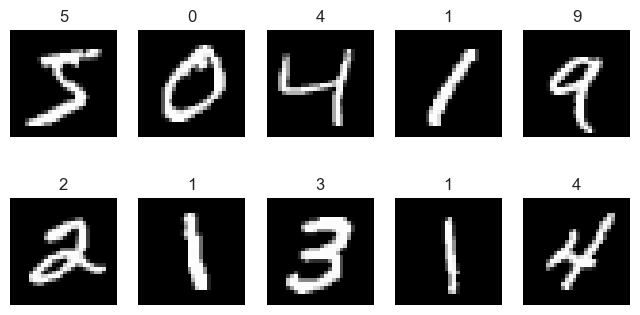

In [27]:
fig, axes = plt.subplots(2,5, figsize=(8,4))

for i, ax in enumerate(axes.flat):
    img, label = train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.show()

### PCA Analysis

We use PCA to project the high dimensional image data 784D into 2D. This is nessesary to visualize the structure of the data and to check whether classes are linearly separable

The results show us that there are obvious cluster, but the classes are not perfectly separable which means that a simple linear model may struggle with the data.


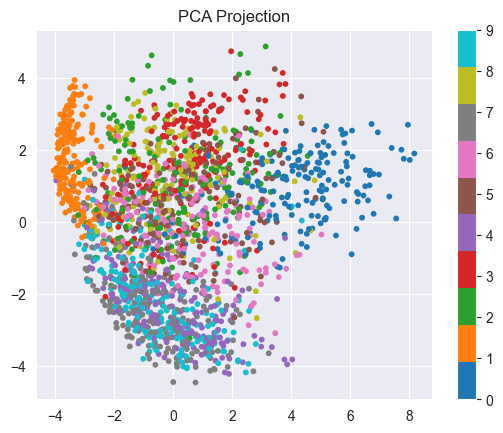

In [28]:
subset = torch.stack([train[i][0].view(-1) for i in range(2000)])
subset_labels = [train[i][1] for i in range(2000)]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(subset)

plt.scatter(X_pca[:,0], X_pca[:,1], c=subset_labels, cmap='tab10', s=10)
plt.colorbar()
plt.title("PCA Projection")
plt.show()

# 4. Model

### Problem Definition
The goal is to achieve Multiclass classification (10 classes: digits 0–9)

### Baseline Model

We start with a simple linear model with 784 features (pixels) as input and 10 classes as output.
This model is fast to train but is only able to model linear relationships.


### Baseline model with linear classification

In [29]:
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(28*28, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

model = BaselineModel().to(DEVICE)

### Loss Function and Optimizer

We use:
CrossEntropyLoss & Adam optimizer

This combination is a common default choice for neural networks.

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 5. Training

The training is conducted in the following steps:
1. Forward pass (prediction)
2. Compute loss
3. Backpropagation
4. Update weights

We store the loss per epoch to analyze the learning progress.

In [31]:
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 0.5462
Epoch 2, Loss: 0.3236
Epoch 3, Loss: 0.2953
Epoch 4, Loss: 0.2819
Epoch 5, Loss: 0.2738


### Interpretation of Loss Curve

A decreasing loss indicates that the model is learning and the predictions are improving.

If the loss stagnates is an indictor for a model that is too simple or a model with poorly chosen hyperparameters


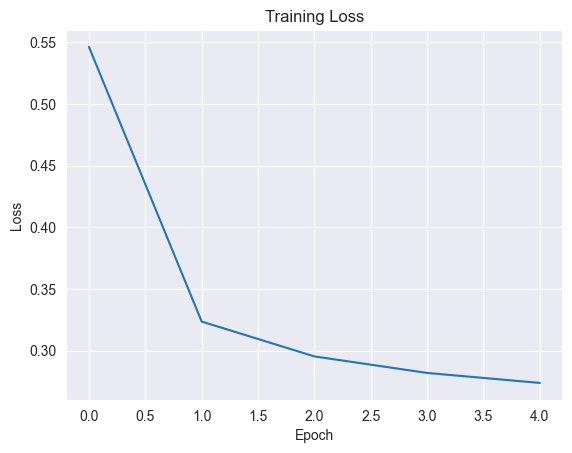

In [32]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 6. Evaluation

For the evaluation, we look at the accuracy and the confusion matrix.

Accuracy is an good indicator because it is simple and suitable for balanced datasets like MNIST.

In [33]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9261


### Interpretation of Confusion Matrix

The matrix shows  which classes are correctly predicted and where the model makes mistakes.

We can see that our model has the typical confusion between visually similar digits (e.g., 3 and 5).

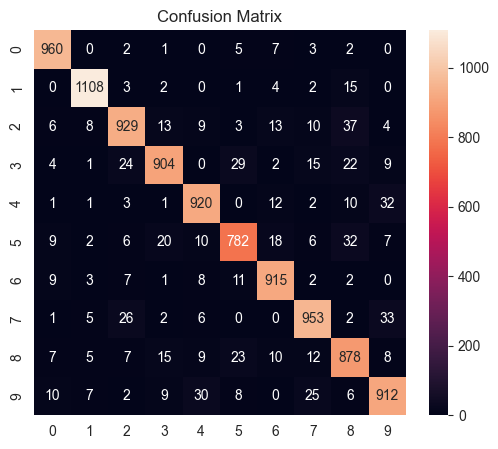

In [34]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Why Test Data?

Test data is so important because it contains unseen data and simulates real-world usage

Without the test data, the risk of overfitting and overly optimistic results would arise.

# 7. Model Improvement

We will improve our current model by using multiple layers (deep learning) and nonlinear activation functions (ReLU) instead of the linear methods used before.

This will terminate the limited expressiveness and maks it possible for the new model to learn mor complex patterns.


In [35]:
class ImprovedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

model2 = ImprovedModel().to(DEVICE)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=LEARNING_RATE)

### Training

In [36]:
train_losses2 = []

for epoch in range(EPOCHS):
    model2.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer2.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer2.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses2.append(epoch_loss)

    print(f"[Improved] Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

[Improved] Epoch 1, Loss: 0.3392
[Improved] Epoch 2, Loss: 0.1410
[Improved] Epoch 3, Loss: 0.0972
[Improved] Epoch 4, Loss: 0.0737
[Improved] Epoch 5, Loss: 0.0584


### Evaluation

In [37]:
model2.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy2 = correct / total
print("Improved Accuracy:", accuracy2)

Improved Accuracy: 0.9735


### Model Comparison

We compare the baseline accuracy and the improved accuracy of both models.

The result shows that the improved model achieves higher accuracy.

This means that nonlinear models are better suited for image data but multi-layer networks can capture more complex structures, which confirms our hypothesis from the PCA analysis.

In [38]:
print("Baseline Accuracy:", accuracy)
print("Improved Accuracy:", accuracy2)

Baseline Accuracy: 0.9261
Improved Accuracy: 0.9735
